# Stage 8-2: RF–XGBoost Common Probability-SHAP Comparison

RF and XGBoost are compared using the same model-agnostic SHAP procedure on predicted probabilities, with the same held-out cases, transformed predictors, 100-participant training background and permutation budget.


## Part 1: Input data and analysis checks

In [1]:
# 1: Import packages

# Load the packages needed for the common probability-SHAP comparison.
from pathlib import Path
from time import perf_counter
import json
import sys

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import shap
import xgboost as xgb

from IPython.display import display
from scipy import sparse
from scipy.stats import spearmanr
from sklearn.compose import ColumnTransformer
from sklearn.ensemble import RandomForestClassifier
from sklearn.impute import SimpleImputer
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import OneHotEncoder
from sklearn.utils.class_weight import compute_sample_weight
from xgboost import XGBClassifier

print("Python:", sys.version.split()[0])
print("SHAP:", shap.__version__)
print("XGBoost:", xgb.__version__)

Python: 3.10.19
SHAP: 0.49.1
XGBoost: 3.2.0


In [2]:
# 2: Set project paths

working_directory = Path.cwd().resolve()

project_root = next(
    (
        directory
        for directory in [working_directory, *working_directory.parents]
        if (
            directory
            / "data_derived"
            / "stage_3_final_modelling_dataset"
            / "final_modelling_dataset.csv"
        ).is_file()
        and (
            directory
            / "data_derived"
            / "stage_8_shap_interpretation"
            / "stage_8_shap_background.csv"
        ).is_file()
    ),
    None,
)

if project_root is None:
    raise FileNotFoundError("Required modelling and Stage 8 inputs could not be located.")

data_derived = project_root / "data_derived"

stage_2_dir = data_derived / "stage_2_predictor_construction"
stage_3_dir = data_derived / "stage_3_final_modelling_dataset"
stage_4_dir = data_derived / "stage_4_modelling_design"
stage_6_dir = data_derived / "stage_6_held_out_test_evaluation"
stage_8_dir = data_derived / "stage_8_shap_interpretation"

stage_8_dir.mkdir(parents=True, exist_ok=True)


In [3]:
# 3: Define required files

# Require the fixed modelling records and the saved Stage 8 RF background.
paths = {
    "data": stage_3_dir / "final_modelling_dataset.csv",
    "split": stage_4_dir / "stage_4_train_test_split.csv",
    "roles": stage_4_dir / "stage_4_predictor_preprocessing_roles.csv",
    "search": stage_4_dir / "stage_4_model_search_specification.csv",
    "model specifications": stage_6_dir / "stage_6_frozen_model_specifications.csv",
    "test predictions": stage_6_dir / "stage_6_test_predictions.csv",
    "background": stage_8_dir / "stage_8_shap_background.csv",
    "RF feature map": stage_8_dir / "stage_8_rf_feature_mapping.csv",
}

missing = [name for name, path in paths.items() if not path.is_file()]

if missing:
    raise FileNotFoundError("Missing input file(s): " + ", ".join(missing))

print("Required files:", len(paths))

Required files: 8


In [4]:
# 4: Load the fixed records

# Read the same data, split, preprocessing roles and Stage 6 outputs.
data = pd.read_csv(paths["data"], dtype={"NSID": "string"})
split = pd.read_csv(paths["split"], dtype={"NSID": "string"})
roles = pd.read_csv(paths["roles"])
search_spec = pd.read_csv(paths["search"])
model_spec = pd.read_csv(paths["model specifications"])
stage_6_predictions = pd.read_csv(
    paths["test predictions"],
    dtype={"NSID": "string"},
)
background_register = pd.read_csv(
    paths["background"],
    dtype={"NSID": "string"},
)
rf_feature_map = pd.read_csv(paths["RF feature map"])

print("Saved background participants:", len(background_register))

Saved background participants: 500


In [5]:
# 5: Prepare the fixed train and test samples

# Apply the fixed Stage 4 split and predictor roles.
train_ids = set(split.loc[split["sample"].eq("Training"), "NSID"])
test_ids = set(split.loc[split["sample"].eq("Test"), "NSID"])

train = data.loc[data["NSID"].isin(train_ids)].copy().reset_index(drop=True)
test = data.loc[data["NSID"].isin(test_ids)].copy().reset_index(drop=True)

predictors = roles["Predictor"].tolist()
numeric = roles.loc[
    roles["Preprocessing role"].eq("Numeric"),
    "Predictor",
].tolist()
categorical = roles.loc[
    roles["Preprocessing role"].eq("Categorical"),
    "Predictor",
].tolist()

for predictor in numeric:
    train[predictor] = pd.to_numeric(train[predictor], errors="raise")
    test[predictor] = pd.to_numeric(test[predictor], errors="raise")

code_to_class = {1: 0, 4: 1, 5: 2, 6: 3}
train["y"] = train["age18_outcome_code"].map(code_to_class).astype(int)
test["y"] = test["age18_outcome_code"].map(code_to_class).astype(int)

print("Training participants:", len(train))
print("Test participants:", len(test))
print("Predictors:", len(predictors))

Training participants: 7619
Test participants: 1905
Predictors: 69


In [6]:
# 6: Check fixed inputs

# Confirm the common comparison sample and predictor structure.
input_checks = {
    "7,619 training participants": len(train) == 7_619,
    "1,905 held-out test participants": len(test) == 1_905,
    "69 original predictors": len(predictors) == 69,
    "500 saved background participants": len(background_register) == 500,
    "Background IDs are training IDs": set(background_register["NSID"]).issubset(train_ids),
    "RF feature map contains 69 predictors": rf_feature_map["Original predictor"].nunique() == 69,
}

input_audit = pd.DataFrame({
    "Check": input_checks.keys(),
    "Passed": input_checks.values(),
})

display(input_audit)

if not input_audit["Passed"].all():
    raise AssertionError("Common comparison inputs are not aligned.")

,Check,Passed
0,"7,619 training participants",True
1,"1,905 held-out test participants",True
2,69 original predictors,True
3,500 saved background participants,True
4,Background IDs are training IDs,True
5,RF feature map contains 69 predictors,True


## Part 2: RF and XGBoost prediction reproduction

In [7]:
# 1: Read the fixed model random state

# Use the random state registered in the modelling design.
search_index = search_spec.set_index("Model")
rf_fixed = json.loads(search_index.loc["Random forest", "Fixed parameters"])
model_random_state = int(rf_fixed["random_state"])

print("Model random state:", model_random_state)

Model random state: 424242


In [8]:
# 2: Build the common tree preprocessor

# Apply the same tree-model preprocessing used by RF and XGBoost.
tree_preprocessor = ColumnTransformer([
    ("numeric", Pipeline([
        ("imputer", SimpleImputer(strategy="median")),
    ]), numeric),
    ("categorical", Pipeline([
        ("imputer", SimpleImputer(strategy="most_frequent")),
        ("encoder", OneHotEncoder(
            handle_unknown="ignore",
            drop="if_binary",
        )),
    ]), categorical),
])

tree_preprocessor.fit(train[predictors])

feature_names = tree_preprocessor.get_feature_names_out().tolist()

def dense_array(values):
    if sparse.issparse(values):
        return values.toarray()
    return np.asarray(values)

tree_train = dense_array(tree_preprocessor.transform(train[predictors]))
tree_test = dense_array(tree_preprocessor.transform(test[predictors]))

print("Transformed features:", len(feature_names))

Transformed features: 118


In [9]:
# 3: Check transformed-feature alignment

# Confirm the feature names match the completed RF Stage 8 mapping.
rf_feature_names = (
    rf_feature_map
    .sort_values("Position")["Transformed feature"]
    .tolist()
)

feature_audit = pd.DataFrame([{
    "RF feature-map columns": len(rf_feature_names),
    "Common transformed columns": len(feature_names),
    "Names and order match": rf_feature_names == feature_names,
}])

display(feature_audit)

if not feature_audit["Names and order match"].all():
    raise AssertionError("Transformed feature order does not match Stage 8 RF.")

,RF feature-map columns,Common transformed columns,Names and order match
0,118,118,True


In [10]:
# 4: Fit the fixed RF and XGBoost models

# Reconstruct the frozen Stage 6 specifications on the full training sample.
fitted_models = {}

rf_row = model_spec.loc[model_spec["Model"].eq("RF")].iloc[0]
rf_parameters = json.loads(rf_row["Selected parameters"])
rf_weighting = rf_row["Selected weighting mode"]

rf_model = RandomForestClassifier(
    **rf_parameters,
    min_samples_split=2,
    class_weight="balanced" if rf_weighting == "Balanced" else None,
    n_jobs=-1,
    random_state=model_random_state,
)
rf_model.fit(tree_train, train["y"])
fitted_models["RF"] = rf_model

xgb_row = model_spec.loc[model_spec["Model"].eq("XGBoost")].iloc[0]
xgb_parameters = json.loads(xgb_row["Selected parameters"])
xgb_weighting = xgb_row["Selected weighting mode"]

xgb_model = XGBClassifier(
    **xgb_parameters,
    objective="multi:softprob",
    num_class=4,
    eval_metric="mlogloss",
    tree_method="hist",
    n_jobs=-1,
    random_state=model_random_state,
    verbosity=0,
)

if xgb_weighting == "Balanced":
    xgb_weights = compute_sample_weight("balanced", train["y"])
    xgb_model.fit(tree_train, train["y"], sample_weight=xgb_weights)
else:
    xgb_model.fit(tree_train, train["y"])

fitted_models["XGBoost"] = xgb_model

print("Models fitted:", list(fitted_models))

Models fitted: ['RF', 'XGBoost']


In [11]:
# 5: Reproduce Stage 6 held-out outputs

# Stop unless both fitted models reproduce the saved Stage 6 results.
probability_columns = [
    "Probability Education",
    "Probability Employment",
    "Probability Apprenticeship or training",
    "Probability Unemployment or inactivity (NEET)",
]

reproduction_rows = []

for model_name, model in fitted_models.items():
    stored = (
        stage_6_predictions.loc[stage_6_predictions["Model"].eq(model_name)]
        .set_index("NSID")
        .reindex(test["NSID"])
    )

    predicted = model.predict(tree_test).astype(int)
    probabilities = model.predict_proba(tree_test)
    stored_probabilities = stored[probability_columns].to_numpy()

    reproduction_rows.append({
        "Model": model_name,
        "Predictions match": np.array_equal(
            predicted,
            stored["Predicted internal class"].to_numpy(dtype=int),
        ),
        "Probabilities match": np.allclose(
            probabilities,
            stored_probabilities,
            atol=1e-10,
            rtol=1e-8,
        ),
        "Max probability difference": np.max(
            np.abs(probabilities - stored_probabilities)
        ),
    })

reproduction_audit = pd.DataFrame(reproduction_rows)
display(reproduction_audit)

if not reproduction_audit[
    ["Predictions match", "Probabilities match"]
].all().all():
    raise AssertionError("Stage 6 outputs were not reproduced.")

,Model,Predictions match,Probabilities match,Max probability difference
0,RF,True,True,3.330669e-16
1,XGBoost,True,True,1.110223e-16


In [12]:
# 6: Save the reproduction audit

# Keep the model reproduction check with the comparison outputs.
reproduction_audit.to_csv(
    stage_8_dir / "stage_8_common_probability_model_reproduction.csv",
    index=False,
)

print("Saved reproduction audit.")

Saved reproduction audit.


## Part 3: Shared 100-participant training background

In [13]:
# 1: Select the common background

# Take a reproducible 100-participant subset of the saved training background.
common_background_register = (
    background_register
    .sample(n=100, random_state=model_random_state)
    .reset_index(drop=True)
)

common_background_ids = common_background_register["NSID"].tolist()

common_background_data = (
    train.set_index("NSID")
    .loc[common_background_ids, predictors]
    .reset_index(drop=True)
)

common_background = dense_array(
    tree_preprocessor.transform(common_background_data)
)

common_background_register.to_csv(
    stage_8_dir / "stage_8_common_probability_background_100.csv",
    index=False,
)

print("Common background participants:", len(common_background_register))
print("Common background shape:", common_background.shape)

Common background participants: 100
Common background shape: (100, 118)


In [14]:
# 2: Check the common comparison design

# Confirm both models will use the same probability-scale inputs.
comparison_checks = {
    "100 common background participants": len(common_background_register) == 100,
    "Background IDs are training IDs": set(common_background_ids).issubset(train_ids),
    "118 transformed features": common_background.shape[1] == 118,
    "1,905 held-out cases": tree_test.shape[0] == 1_905,
    "Four probability outputs": len(probability_columns) == 4,
}

comparison_audit = pd.DataFrame({
    "Check": comparison_checks.keys(),
    "Passed": comparison_checks.values(),
})

display(comparison_audit)

if not comparison_audit["Passed"].all():
    raise AssertionError("Common probability-SHAP design check failed.")

,Check,Passed
0,100 common background participants,True
1,Background IDs are training IDs,True
2,118 transformed features,True
3,"1,905 held-out cases",True
4,Four probability outputs,True


## Part 4: Model-agnostic probability SHAP


In [15]:
# 1: Build the common masker and explainers

# Use one independent masker for both model probability functions.
common_masker = shap.maskers.Independent(
    common_background,
    max_samples=100,
)

rf_explainer = shap.PermutationExplainer(
    rf_model.predict_proba,
    common_masker,
    feature_names=feature_names,
    seed=model_random_state,
)

xgb_explainer = shap.PermutationExplainer(
    xgb_model.predict_proba,
    common_masker,
    feature_names=feature_names,
    seed=model_random_state,
)

max_evals = 2 * len(feature_names) + 1

print("Minimum evaluations per explained case:", max_evals)

Minimum evaluations per explained case: 237


In [16]:
# 2: Run a small timing check

# Time five held-out cases before the full calculation.
timing_rows = []

for model_name, explainer in [
    ("RF", rf_explainer),
    ("XGBoost", xgb_explainer),
]:
    start = perf_counter()

    small_explanation = explainer(
        tree_test[:5],
        max_evals=max_evals,
        silent=True,
    )

    timing_rows.append({
        "Model": model_name,
        "Cases": 5,
        "Seconds": perf_counter() - start,
    })

timing_check = pd.DataFrame(timing_rows)
display(timing_check)

,Model,Cases,Seconds
0,RF,5,7.163728
1,XGBoost,5,1.467156


In [17]:
# 3: Calculate RF probability SHAP

# Explain all held-out RF probabilities with the common procedure.
start = perf_counter()

rf_common_explanation = rf_explainer(
    tree_test,
    max_evals=max_evals,
    silent=False,
)

rf_common_seconds = perf_counter() - start
rf_common_shap = np.asarray(rf_common_explanation.values)

print("RF SHAP shape:", rf_common_shap.shape)
print("RF seconds:", round(rf_common_seconds, 1))

PermutationExplainer explainer: 1906it [10:44,  2.90it/s]                                                              

RF SHAP shape: (1905, 118, 4)
RF seconds: 644.5


In [18]:
# 4: Check and save RF probability SHAP

# Confirm local additivity on the RF predicted-probability scale.
rf_probabilities = rf_model.predict_proba(tree_test)
rf_rebuilt = (
    rf_common_shap.sum(axis=1)
    + np.asarray(rf_common_explanation.base_values)
)
rf_max_error = np.max(np.abs(rf_rebuilt - rf_probabilities))

rf_shap_audit = pd.DataFrame([{
    "Model": "RF",
    "Shape": str(rf_common_shap.shape),
    "Max probability error": rf_max_error,
    "Passed": rf_max_error < 1e-6,
}])

display(rf_shap_audit)

if not rf_shap_audit["Passed"].all():
    raise AssertionError("RF common probability-SHAP audit failed.")

np.savez_compressed(
    stage_8_dir / "stage_8_rf_common_probability_shap.npz",
    values=rf_common_shap,
    base_values=np.asarray(rf_common_explanation.base_values),
)

print("Saved RF common probability SHAP.")

,Model,Shape,Max probability error,Passed
0,RF,"(1905, 118, 4)",1.998401e-15,True


Saved RF common probability SHAP.


In [19]:
# 5: Calculate XGBoost probability SHAP

# Explain all held-out XGBoost probabilities with the same procedure.
start = perf_counter()

xgb_common_explanation = xgb_explainer(
    tree_test,
    max_evals=max_evals,
    silent=False,
)

xgb_common_seconds = perf_counter() - start
xgb_common_shap = np.asarray(xgb_common_explanation.values)

print("XGBoost SHAP shape:", xgb_common_shap.shape)
print("XGBoost seconds:", round(xgb_common_seconds, 1))

PermutationExplainer explainer: 1906it [07:38,  4.07it/s]                                                              

XGBoost SHAP shape: (1905, 118, 4)
XGBoost seconds: 458.3


In [20]:
# 6: Check and save XGBoost probability SHAP

# Confirm local additivity on the XGBoost predicted-probability scale.
xgb_probabilities = xgb_model.predict_proba(tree_test)
xgb_rebuilt = (
    xgb_common_shap.sum(axis=1)
    + np.asarray(xgb_common_explanation.base_values)
)
xgb_max_error = np.max(np.abs(xgb_rebuilt - xgb_probabilities))

xgb_shap_audit = pd.DataFrame([{
    "Model": "XGBoost",
    "Shape": str(xgb_common_shap.shape),
    "Max probability error": xgb_max_error,
    "Passed": xgb_max_error < 1e-6,
}])

display(xgb_shap_audit)

if not xgb_shap_audit["Passed"].all():
    raise AssertionError("XGBoost common probability-SHAP audit failed.")

np.savez_compressed(
    stage_8_dir / "stage_8_xgboost_common_probability_shap.npz",
    values=xgb_common_shap,
    base_values=np.asarray(xgb_common_explanation.base_values),
)

print("Saved XGBoost common probability SHAP.")

,Model,Shape,Max probability error,Passed
0,XGBoost,"(1905, 118, 4)",5.551115e-16,True


Saved XGBoost common probability SHAP.


## Part 5: Aggregate SHAP values to 69 predictors

In [21]:
# 1: Group encoded SHAP values

# Sum signed encoded attributions within each original predictor.
original_predictors = (
    rf_feature_map
    .sort_values("Position")["Original predictor"]
    .drop_duplicates()
    .tolist()
)

def group_shap(values):
    grouped = np.zeros(
        (values.shape[0], len(original_predictors), values.shape[2])
    )

    for predictor_index, predictor in enumerate(original_predictors):
        positions = (
            rf_feature_map.loc[
                rf_feature_map["Original predictor"].eq(predictor),
                "Position",
            ]
            .astype(int)
            .to_numpy()
        )

        grouped[:, predictor_index, :] = values[:, positions, :].sum(axis=1)

    return grouped

rf_grouped = group_shap(rf_common_shap)
xgb_grouped = group_shap(xgb_common_shap)

print("RF grouped shape:", rf_grouped.shape)
print("XGBoost grouped shape:", xgb_grouped.shape)

RF grouped shape: (1905, 69, 4)
XGBoost grouped shape: (1905, 69, 4)


In [22]:
# 2: Create destination-specific importance tables

# Calculate mean absolute grouped attribution for each destination.
outcome_labels = {
    0: "Education",
    1: "Employment",
    2: "Apprenticeship or training",
    3: "Unemployment or inactivity (NEET)",
}

def importance_table(grouped_values, model_name):
    rows = []

    for class_number, outcome in outcome_labels.items():
        values = np.mean(
            np.abs(grouped_values[:, :, class_number]),
            axis=0,
        )

        table = pd.DataFrame({
            "Model": model_name,
            "Outcome": outcome,
            "Original predictor": original_predictors,
            "Mean absolute SHAP": values,
        })

        table["Rank"] = (
            table["Mean absolute SHAP"]
            .rank(method="min", ascending=False)
            .astype(int)
        )

        rows.append(table)

    return pd.concat(rows, ignore_index=True)

rf_common_importance = importance_table(rf_grouped, "RF")
xgb_common_importance = importance_table(xgb_grouped, "XGBoost")

common_importance = pd.concat(
    [rf_common_importance, xgb_common_importance],
    ignore_index=True,
)

common_importance.to_csv(
    stage_8_dir / "stage_8_common_probability_importance_by_destination.csv",
    index=False,
)

display(
    common_importance.loc[common_importance["Rank"].le(6)]
    .sort_values(["Outcome", "Model", "Rank"])
)

,Model,Outcome,Original predictor,Mean absolute SHAP,Rank
147,RF,Apprenticeship or training,higher_education_application_likelihood,0.017596,1
157,RF,Apprenticeship or training,parental_higher_education_expectation_pretrans...,0.014187,2
187,RF,Apprenticeship or training,expected_post16_route,0.011722,3
170,RF,Apprenticeship or training,parental_training_apprenticeship_discussion_pr...,0.010413,4
177,RF,Apprenticeship or training,ethnicity,0.008437,5
175,RF,Apprenticeship or training,apprenticeship_guidance_profile_pretransition,0.007973,6
433,XGBoost,Apprenticeship or training,parental_higher_education_expectation_pretrans...,0.019025,1
415,XGBoost,Apprenticeship or training,highest_parental_qualification_code,0.018816,2
428,XGBoost,Apprenticeship or training,academic_self_concept_score,0.014596,3
423,XGBoost,Apprenticeship or training,higher_education_application_likelihood,0.014195,4


## Part 6: RF–XGBoost comparison


In [23]:
# 1: Compare probability-scale magnitudes and ranks

# Join RF and XGBoost attributions for the same predictor and destination.
rf_table = rf_common_importance.rename(columns={
    "Mean absolute SHAP": "RF mean |SHAP|",
    "Rank": "RF rank",
}).drop(columns="Model")

xgb_table = xgb_common_importance.rename(columns={
    "Mean absolute SHAP": "XGBoost mean |SHAP|",
    "Rank": "XGBoost rank",
}).drop(columns="Model")

comparison = rf_table.merge(
    xgb_table,
    on=["Outcome", "Original predictor"],
    how="inner",
)

comparison["Magnitude difference (XGBoost - RF)"] = (
    comparison["XGBoost mean |SHAP|"]
    - comparison["RF mean |SHAP|"]
)

comparison["Absolute magnitude difference"] = np.abs(
    comparison["Magnitude difference (XGBoost - RF)"]
)

comparison["RF top 6"] = comparison["RF rank"].le(6)
comparison["XGBoost top 6"] = comparison["XGBoost rank"].le(6)

comparison.to_csv(
    stage_8_dir / "stage_8_rf_xgboost_common_probability_comparison.csv",
    index=False,
)

display(
    comparison.sort_values(
        ["Outcome", "Absolute magnitude difference"],
        ascending=[True, False],
    ).groupby("Outcome").head(10)
)

,Outcome,Original predictor,RF mean |SHAP|,RF rank,XGBoost mean |SHAP|,XGBoost rank,Magnitude difference (XGBoost - RF),Absolute magnitude difference,RF top 6,XGBoost top 6
139,Apprenticeship or training,highest_parental_qualification_code,0.006864,8,0.018816,2,0.011952,0.011952,False,True
148,Apprenticeship or training,school_attitude_score,0.003161,13,0.013204,7,0.010042,0.010042,False,False
176,Apprenticeship or training,sex,0.005823,10,0.013906,5,0.008083,0.008083,False,True
152,Apprenticeship or training,academic_self_concept_score,0.007675,7,0.014596,3,0.006921,0.006921,False,True
171,Apprenticeship or training,teacher_guidance_frequency_index_pretransition,0.002132,21,0.008250,13,0.006119,0.006119,False,False
165,Apprenticeship or training,parent_school_day_discussion_frequency_pretran...,0.001478,31,0.007217,16,0.005739,0.005739,False,False
180,Apprenticeship or training,family_nssec_code,0.002908,14,0.008405,12,0.005496,0.005496,False,False
164,Apprenticeship or training,parent_communication_frequency_score_pretransi...,0.002510,17,0.007793,14,0.005283,0.005283,False,False
177,Apprenticeship or training,ethnicity,0.008437,5,0.013465,6,0.005027,0.005027,True,True
157,Apprenticeship or training,parental_higher_education_expectation_pretrans...,0.014187,2,0.019025,1,0.004838,0.004838,True,True


In [24]:
# 2: Summarise rank agreement

agreement_rows = []

for outcome in outcome_labels.values():
    table = comparison.loc[
        comparison["Outcome"].eq(outcome)
    ].copy()

    rho = spearmanr(
        table["RF mean |SHAP|"],
        table["XGBoost mean |SHAP|"],
    ).statistic

    rf_top = set(
        table.loc[table["RF top 6"], "Original predictor"]
    )
    xgb_top = set(
        table.loc[table["XGBoost top 6"], "Original predictor"]
    )

    agreement_rows.append({
        "Outcome": outcome,
        "Spearman rho": rho,
        "Shared top 6": len(rf_top & xgb_top),
    })

agreement_summary = pd.DataFrame(agreement_rows)

agreement_summary.to_csv(
    stage_8_dir / "stage_8_rf_xgboost_common_probability_agreement.csv",
    index=False,
)

display(agreement_summary)


,Outcome,Spearman rho,Shared top 6
0,Education,0.875667,5
1,Employment,0.892656,4
2,Apprenticeship or training,0.831385,3
3,Unemployment or inactivity (NEET),0.865619,5


In [25]:
# 3: Show the union of top-six predictors

# Display directly comparable probability-scale attributions.
top_union = comparison.loc[
    comparison["RF top 6"] | comparison["XGBoost top 6"]
].copy()

display(
    top_union.sort_values(
        ["Outcome", "RF rank", "XGBoost rank"]
    )
)

,Outcome,Original predictor,RF mean |SHAP|,RF rank,XGBoost mean |SHAP|,XGBoost rank,Magnitude difference (XGBoost - RF),Absolute magnitude difference,RF top 6,XGBoost top 6
147,Apprenticeship or training,higher_education_application_likelihood,0.017596,1,0.014195,4,-0.003402,0.003402,True,True
157,Apprenticeship or training,parental_higher_education_expectation_pretrans...,0.014187,2,0.019025,1,0.004838,0.004838,True,True
187,Apprenticeship or training,expected_post16_route,0.011722,3,0.011468,9,-0.000254,0.000254,True,False
170,Apprenticeship or training,parental_training_apprenticeship_discussion_pr...,0.010413,4,0.012131,8,0.001718,0.001718,True,False
177,Apprenticeship or training,ethnicity,0.008437,5,0.013465,6,0.005027,0.005027,True,True
175,Apprenticeship or training,apprenticeship_guidance_profile_pretransition,0.007973,6,0.008773,11,0.000799,0.000799,True,False
152,Apprenticeship or training,academic_self_concept_score,0.007675,7,0.014596,3,0.006921,0.006921,False,True
139,Apprenticeship or training,highest_parental_qualification_code,0.006864,8,0.018816,2,0.011952,0.011952,False,True
176,Apprenticeship or training,sex,0.005823,10,0.013906,5,0.008083,0.008083,False,True
9,Education,higher_education_application_likelihood,0.053069,1,0.070461,1,0.017391,0.017391,True,True


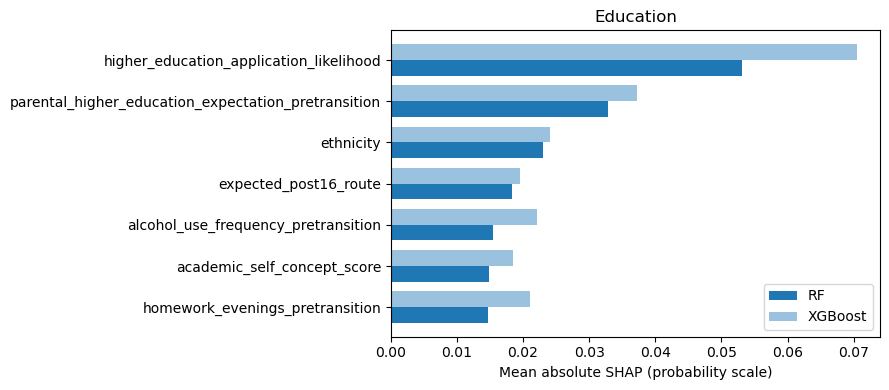

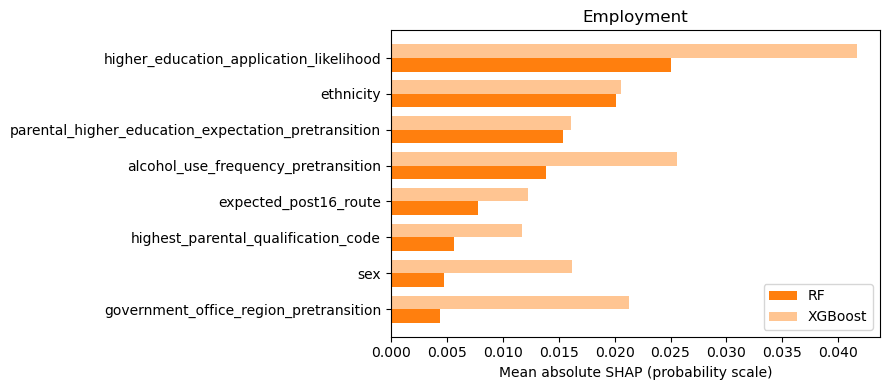

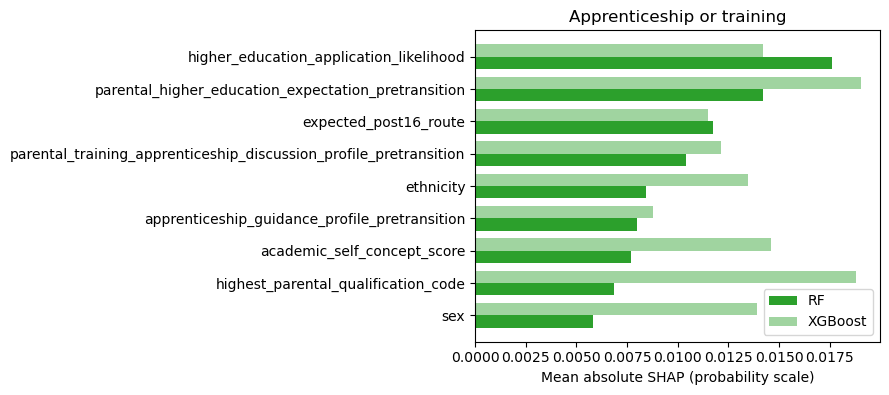

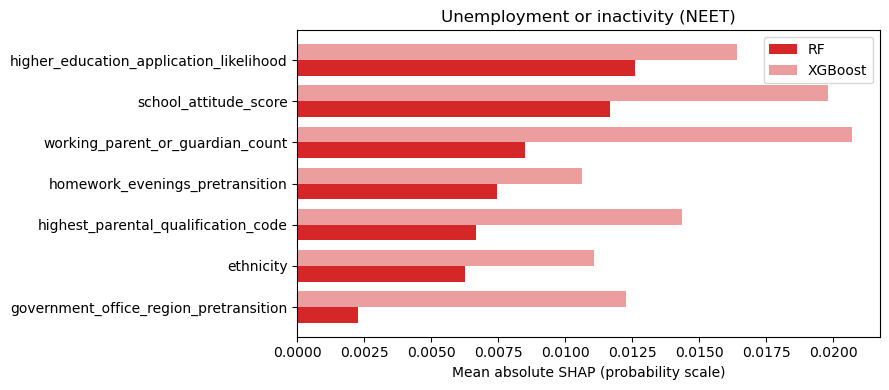

In [26]:
# 4: Plot the common probability-scale comparison

# Compare RF and XGBoost mean absolute SHAP for the top-predictor union.
outcome_colours = {
    "Education": "tab:blue",
    "Employment": "tab:orange",
    "Apprenticeship or training": "tab:green",
    "Unemployment or inactivity (NEET)": "tab:red",
}

for outcome in outcome_labels.values():
    plot_data = (
        top_union.loc[top_union["Outcome"].eq(outcome)]
        .sort_values("RF mean |SHAP|", ascending=True)
    )

    y = np.arange(len(plot_data))
    height = 0.38

    fig, ax = plt.subplots(figsize=(9, max(4, len(plot_data) * 0.45)))

    ax.barh(
        y - height / 2,
        plot_data["RF mean |SHAP|"],
        height=height,
        label="RF",
        color=outcome_colours[outcome],
    )

    ax.barh(
        y + height / 2,
        plot_data["XGBoost mean |SHAP|"],
        height=height,
        label="XGBoost",
        color=outcome_colours[outcome],
        alpha=0.45,
    )

    ax.set_yticks(y)
    ax.set_yticklabels(plot_data["Original predictor"])
    ax.set_xlabel("Mean absolute SHAP (probability scale)")
    ax.set_title(outcome)
    ax.legend()
    fig.tight_layout()

    safe_name = (
        outcome.lower()
        .replace(" ", "_")
        .replace("/", "_")
        .replace("(", "")
        .replace(")", "")
    )

    fig.savefig(
        stage_8_dir / f"stage_8_rf_xgboost_common_probability_{safe_name}.png",
        dpi=300,
        bbox_inches="tight",
    )

    display(fig)
    plt.close(fig)

## Part 7: Final audit


In [27]:
# 1: Complete the comparison audit

# Confirm the common model-agnostic analysis is complete.
final_checks = {
    "RF Stage 6 outputs reproduced": bool(
        reproduction_audit.loc[
            reproduction_audit["Model"].eq("RF"),
            ["Predictions match", "Probabilities match"],
        ].all(axis=None)
    ),
    "XGBoost Stage 6 outputs reproduced": bool(
        reproduction_audit.loc[
            reproduction_audit["Model"].eq("XGBoost"),
            ["Predictions match", "Probabilities match"],
        ].all(axis=None)
    ),
    "Same 100-participant background": len(common_background_register) == 100,
    "RF probability SHAP passed": bool(rf_shap_audit["Passed"].all()),
    "XGBoost probability SHAP passed": bool(xgb_shap_audit["Passed"].all()),
    "69 grouped predictors in RF": rf_grouped.shape[1] == 69,
    "69 grouped predictors in XGBoost": xgb_grouped.shape[1] == 69,
    "Four destinations compared": comparison["Outcome"].nunique() == 4,
}

final_audit = pd.DataFrame({
    "Check": final_checks.keys(),
    "Passed": final_checks.values(),
})

final_audit.to_csv(
    stage_8_dir / "stage_8_rf_xgboost_common_probability_final_audit.csv",
    index=False,
)

display(final_audit)

if not final_audit["Passed"].all():
    raise AssertionError("Common RF-XGBoost comparison audit failed.")

,Check,Passed
0,RF Stage 6 outputs reproduced,True
1,XGBoost Stage 6 outputs reproduced,True
2,Same 100-participant background,True
3,RF probability SHAP passed,True
4,XGBoost probability SHAP passed,True
5,69 grouped predictors in RF,True
6,69 grouped predictors in XGBoost,True
7,Four destinations compared,True


## Interpretation

Using a common probability-scale SHAP procedure showed that RF and XGBoost did not attribute predictions to the 69 predictors in exactly the same way. Some leading predictors were shared across the two models, while their rankings and relative attribution patterns varied by destination.

This comparison shows how interpretation can depend on the fitted machine-learning model, even when the models are evaluated on the same cases and predictor set.